# Assignment 2: Unsupervised Learning on Time Series Data

## Anomaly Detection in Pump Sensor Data

**Group 1:** Finn, Mirko, Mohamed

---

#Framing the problem and the big picture

**1. Defining the problem**

The problem is to detect abnormal operating conditions in an industrial water pump using sensor data.

The dataset contains timestamped measurements from 52 sensors monitoring the pumps behavior, including signals such as pressure, vibration, and other operational parameters.

Since clear labels for failures are not consistently available, the task is formulated as an unsupervised anomaly detection problem. The objective is to identify observations that deviate from normal pump operating patterns, which may indicate abnormal behavior or potential system failures.

**2. How will our solution be used?**

The anomaly detection model can be used to monitor pump sensor data continuously.

New incoming sensor measurements would be analyzed by the trained model, which assigns an anomaly score to each observation. If the score exceeds a predefined threshold, the system can alert maintenance engineers to inspect the pump.

This allows early detection of abnormal operating conditions and supports predictive maintenance, helping prevent unexpected pump failures.

**3. Current solutions and workarounds**

Currently, the pump system is monitored by engineers using sensor dashboards and basic alarm thresholds.

Each sensor measurement can trigger an alert when it exceeds predefined limits. However, these threshold-based systems cannot detect complex anomalies that involve multiple sensors or subtle changes in operating patterns.

The dataset description also indicates that the maintenance team could not identify clear patterns before failures occurred. Therefore, a machine learning based anomaly detection approach may help identify abnormal behavior that is difficult to detect manually.

**4. Problem framing**

The problem is framed as an unsupervised anomaly detection task on multivariate time series data.

The dataset contains timestamped measurements from 52 sensors installed on an industrial water pump. Each observation represents the operating condition of the pump at a specific time.

Since labeled failures are not consistently available, the goal is to identify observations that deviate from normal operating behavior. These deviations may correspond to abnormal pump conditions or early signs of failure.

**5. Performance measurement**

Because the dataset does not provide reliable labels for failures, traditional supervised performance metrics such as accuracy or F1-score cannot be used.

Instead, the model performance is evaluated using:

• the number of detected anomalies  
• visualization of anomalies in the sensor time series  
• separation of anomalies in PCA space  

These approaches help determine whether the model identifies unusual sensor patterns that could correspond to abnormal pump behavior.

**6. Is the performance measure alligned with the business objective?**

Yes. The objective of the system is to detect abnormal pump behavior early in order to prevent system failures.

By identifying unusual sensor patterns and deviations from normal operation, the anomaly detection model can help maintenance teams detect potential issues before a failure occurs.

**7. Minimum performance required to meet business objective**

A useful anomaly detection system should detect clear abnormal operating conditions while avoiding excessive false alarms.

The system should identify significant deviations in sensor signals that may indicate abnormal pump behavior or potential system failure.

**8. Compareable problems and reuseable experience**

Similar anomaly detection problems exist in predictive maintenance and industrial equipment monitoring.

In many industrial systems, sensors continuously measure equipment conditions such as temperature, vibration, and pressure. Machine learning based anomaly detection methods are commonly used to identify abnormal patterns in such sensor data.

**9. Available human expertise**

Maintenance engineers and pump operators have experience with normal and abnormal pump behavior.

Their expertise can help interpret detected anomalies and determine whether unusual sensor patterns correspond to real equipment problems.

**10. Manually problem solving alternatives**

Without machine learning, anomalies would need to be detected by manually monitoring sensor dashboards and inspecting sensor values.

However, with 52 sensors and more than 220,000 observations in the dataset, manual monitoring becomes difficult and time-consuming.

**11. Assumptions by us or others**

We assume that most observations in the dataset represent normal pump operation and that abnormal behavior is relatively rare.

We also assume that unusual patterns in the sensor measurements may indicate abnormal pump conditions or early signs of failure.

**12. Verify assumptions, if possible**

The assumption that anomalies are rare is supported by the Isolation Forest results, where approximately 1% of observations were detected as anomalies.

Many of these anomalies correspond to unusual drops or spikes in the sensor time series, suggesting abnormal operating conditions.


#Dataset Description

Dataset: [pump_sensor_data (Kaggle)](https://www.kaggle.com/datasets/nphantawee/pump-sensor-data) *"Pump sensor data for predictive maintenance"*

The dataset contains multivariate time series data collected from sensors installed on an industrial pump.

The dataset contains 220,320 observations and 52 sensor measurements.

The sensors monitor machine conditions such as pressure, temperature, vibration and other operational signals.

###Dataset structure

| Feature type | Description |
|------|------|
| Timestamp | Time of the sensor measurement |
| Sensor data | 52 sensor measurements describing pump operating conditions |
| Machine status | Indicates the operating state of the pump (not used for training in this unsupervised task) |

#Import necessary libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest

*Load* dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nphantawee/pump-sensor-data")

print("Path to dataset files:", path)

100%|██████████| 37.1M/37.1M [00:01<00:00, 36.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nphantawee/pump-sensor-data/versions/1


In [ ]:
import os

os.listdir(path)

['sensor.csv']

In [ ]:
data = pd.read_csv(path + "/sensor.csv")
print(data.shape)
data.head()

(220320, 55)


,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


Data exploration

In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 55 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      220320 non-null  int64  
 1   timestamp       220320 non-null  object 
 2   sensor_00       210112 non-null  float64
 3   sensor_01       219951 non-null  float64
 4   sensor_02       220301 non-null  float64
 5   sensor_03       220301 non-null  float64
 6   sensor_04       220301 non-null  float64
 7   sensor_05       220301 non-null  float64
 8   sensor_06       215522 non-null  float64
 9   sensor_07       214869 non-null  float64
 10  sensor_08       215213 non-null  float64
 11  sensor_09       215725 non-null  float64
 12  sensor_10       220301 non-null  float64
 13  sensor_11       220301 non-null  float64
 14  sensor_12       220301 non-null  float64
 15  sensor_13       220301 non-null  float64
 16  sensor_14       220299 non-null  float64
 17  sensor_15 

,Unnamed: 0,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
count,220320.000000,210112.000000,219951.000000,220301.000000,220301.000000,220301.000000,220301.000000,215522.000000,214869.000000,215213.000000,...,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,143303.000000,204937.000000
mean,110159.500000,2.372221,47.591611,50.867392,43.752481,590.673936,73.396414,13.501537,15.843152,15.200721,...,35.453455,43.879591,42.656877,43.094984,48.018585,44.340903,150.889044,57.119968,183.049260,202.699667
std,63601.049991,0.412227,3.296666,3.666820,2.418887,144.023912,17.298247,2.163736,2.201155,2.037390,...,10.259521,11.044404,11.576355,12.837520,15.641284,10.442437,82.244957,19.143598,65.258650,109.588607
min,0.000000,0.000000,0.000000,33.159720,31.640620,2.798032,0.000000,0.014468,0.000000,0.028935,...,22.135416,24.479166,25.752316,26.331018,26.331018,27.199070,26.331018,26.620370,27.488426,27.777779
25%,55079.750000,2.438831,46.310760,50.390620,42.838539,626.620400,69.976260,13.346350,15.907120,15.183740,...,32.812500,39.583330,36.747684,36.747684,40.509258,39.062500,83.912030,47.743060,167.534700,179.108800
50%,110159.500000,2.456539,48.133678,51.649300,44.227428,632.638916,75.576790,13.642940,16.167530,15.494790,...,35.156250,42.968750,40.509260,40.219910,44.849540,42.534720,138.020800,52.662040,193.865700,197.338000
75%,165239.250000,2.499826,49.479160,52.777770,45.312500,637.615723,80.912150,14.539930,16.427950,15.697340,...,36.979164,46.614580,45.138890,44.849540,51.215280,46.585650,208.333300,60.763890,219.907400,216.724500
max,220319.000000,2.549016,56.727430,56.032990,48.220490,800.000000,99.999880,22.251160,23.596640,24.348960,...,374.218800,408.593700,1000.000000,320.312500,370.370400,303.530100,561.632000,464.409700,1000.000000,1000.000000


Sensor Distribution

The histogram shows the distribution of values for one of the pump sensors.
This helps identify whether the sensor measurements follow a normal pattern or contain unusual values.

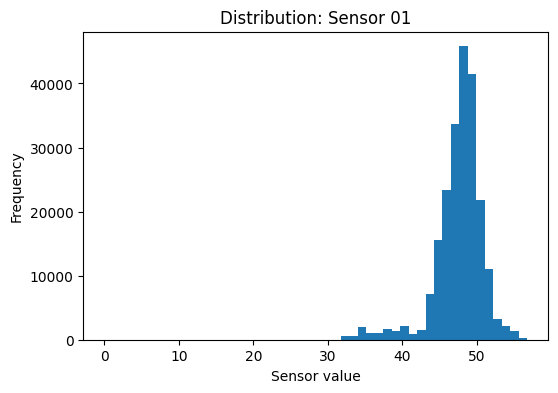

In [ ]:
plt.figure(figsize = (6,4))
plt.hist(data['sensor_01'], bins = 50)
plt.title("Distribution: Sensor 01")
plt.xlabel("Sensor value")
plt.ylabel("Frequency")
plt.show()

Visualzition for one sensor

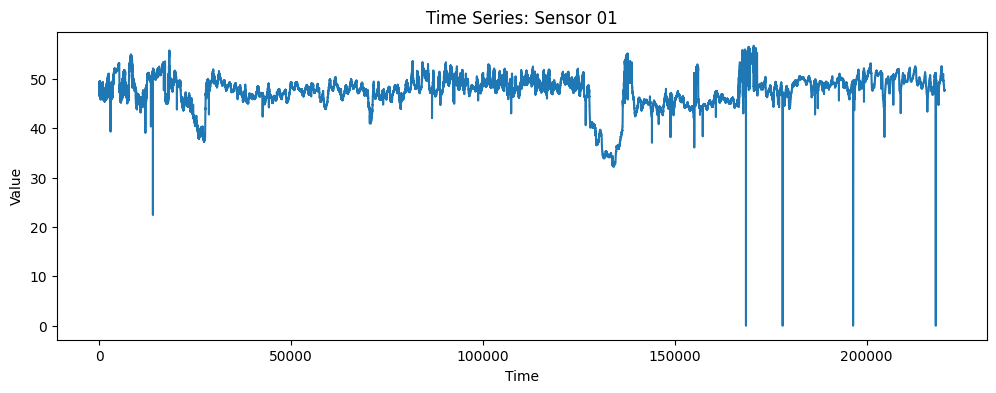

In [ ]:
plt.figure(figsize = (12,4))
plt.plot(data['sensor_01'])
plt.title("Time Series: Sensor 01")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

Data preprocessing

In [ ]:
data = pd.read_csv(path + "/sensor.csv") #Reload the data if needed (just to make sure start from the original data)

sensor_cols = [c for c in data.columns if "sensor" in c.lower()] #Only keep sensor columns, removes columns such as timestamp and machine_status from the ML feature matrix

X_df = data[sensor_cols].copy()

print("Initial shape:", X_df.shape)

X_df = X_df.loc[:, X_df.isna().mean() < 0.9] #Remove sensor columns with too many missing values, keep only columns with less than 90% missing data

print("After dropping columns with too many missing values:", X_df.shape)

X_df = X_df.fillna(X_df.median()) #Fill remaining missing values with median

print("Remaining missing values:", X_df.isna().sum().sum())

scaler = StandardScaler() #All features have comparable scale
X = scaler.fit_transform(X_df) #Fit and transform the cleaned sensor data into a numeric matrix

print("Final X shape:", X.shape)

Initial shape: (220320, 52)
After dropping columns with too many missing values: (220320, 51)
Remaining missing values: 0
Final X shape: (220320, 51)


As we can see, only one column was removed. This is expected since column 15 has no data avaliable.

#Time Series Plot

Visualization that helps identify fluctuations and potential abnormal behavior in the sensor signals over time. Such as trends, drops, spikes.


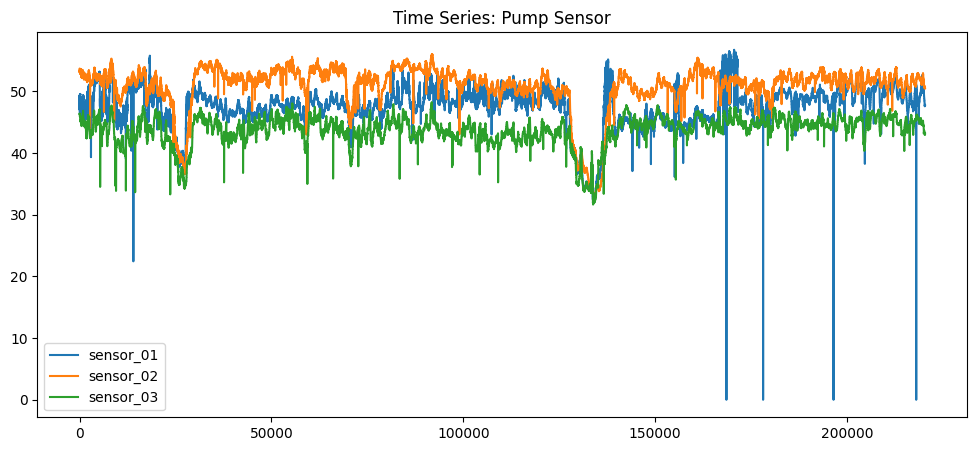

In [ ]:
plt.figure(figsize=(12,5))
for sensor in ['sensor_01','sensor_02','sensor_03']:
  plt.plot(data[sensor], label = sensor)
plt.legend()
plt.title("Time Series: Pump Sensor")
plt.show()

#Correlation Heatmap

Shows relationships between different sensor measurements. Strong correlations may indicate sensors monitoring related physical processes.

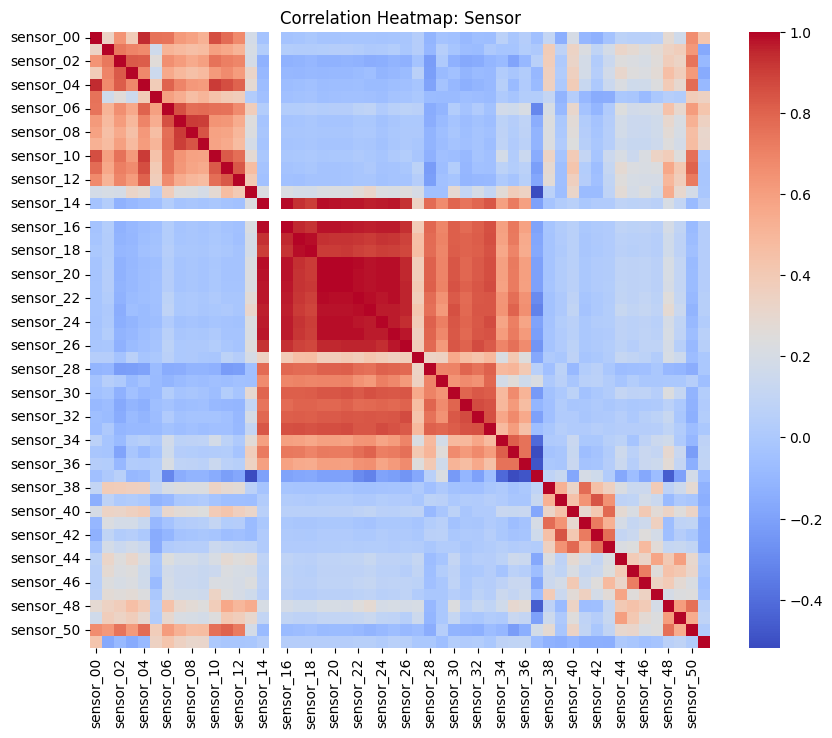

In [ ]:
plt.figure(figsize = (10,8))

sensor_cols = [c for c in data.columns if "sensor" in c.lower()] #All sensor columns gets selected again
corr = data[sensor_cols].corr()

sns.heatmap(corr, cmap = 'coolwarm')

plt.title("Correlation Heatmap: Sensor")
plt.show()

#Chosen methods:

1. K-Means = Baseline clustering

2. Isolation Forest = Dedicated anomaly detection method

3. DBSCAN = Density based anomaly detection

**Method 1: **K**-Means**

KMeans groups observations into clusters representing normal pump operating conditions. Points far from cluster centers can indicate abnormal behavior.

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

data['kmeans_cluster'] = kmeans.fit_predict(X)

**Method 2: Isolation Forest**

Isolation Forest detects anomalies by isolating observations using random decision trees. Anomalies require fewer splits to isolate.

In [ ]:
iso = IsolationForest(contamination = 0.01)

data['iso_anomaly'] = iso.fit_predict(X)
print(data['iso_anomaly'].value_counts())

iso_anomaly
 1    218116
-1      2204
Name: count, dtype: int64


Isolation Forest detected approximately 1% anomalies,
which corresponds to 2204 abnormal observations.
These anomalies correspond to sharp drops or unusual
sensor patterns visible in the time series plots.

This suggests that the model is able to detect abnormal pump behavior
that deviates from normal operating conditions.

#PCA Visualization of Sensor Data

PCA is used to reduce the dimensionality of the sensor data
while preserving the most important variance in the dataset.
This allows visualization of high dimensional sensor patterns.


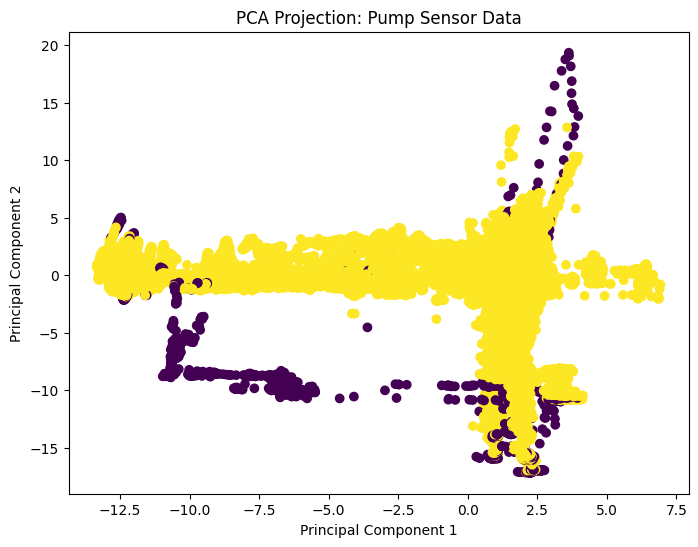

In [ ]:
pca = PCA(n_components = 2, random_state = 42)

X_pca = pca.fit_transform(X)

plt.figure(figsize = (8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c = data['iso_anomaly'])
plt.title("PCA Projection: Pump Sensor Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

**Method 3: DBSCAN**

DBSCAN detects clusters based on data density and labels low-density points as noise. These noise points are interpreted as anomalies.

We need to sample a smaller subset for DBSCAN, since we have a pretty large pumpsett, and after preprocessing there will remain a large amount of rows. DBSCAN on a full X will be to heavy.

In [ ]:
sample_size = 10000
rng = np.random.RandomState(42)
indices = rng.choice(X.shape[0], size = sample_size, replace = False) #Randomly selected indices from the full PCA-transformed dataset
X_dbscan = X_pca[indices] #Sampled PCA observations as input to DBSCAN

In [ ]:
dbscan = DBSCAN(eps = 0.3, min_samples = 10)
dbscan_labels = dbscan.fit_predict(X_dbscan)

print(pd.Series(dbscan_labels).value_counts())

 0     7898
 2      824
-1      437
 5      391
 3       54
 7       54
 11      40
 9       30
 8       23
 17      22
 18      22
 10      19
 23      18
 21      16
 16      15
 15      14
 4       14
 1       13
 14      12
 13      12
 6       11
 24      11
 25      10
 20      10
 12      10
 19      10
 22      10
Name: count, dtype: int64


In [ ]:
dbscan_results = pd.DataFrame(X_dbscan, columns=['PC1', 'PC2'])
dbscan_results['dbscan_cluster'] = dbscan_labels

print(dbscan_results['dbscan_cluster'].value_counts())

dbscan_cluster
 0     7898
 2      824
-1      437
 5      391
 3       54
 7       54
 11      40
 9       30
 8       23
 17      22
 18      22
 10      19
 23      18
 21      16
 16      15
 15      14
 4       14
 1       13
 14      12
 13      12
 6       11
 24      11
 25      10
 20      10
 12      10
 19      10
 22      10
Name: count, dtype: int64


#Anomaly Visualization

Shows normal data and detected anomalies

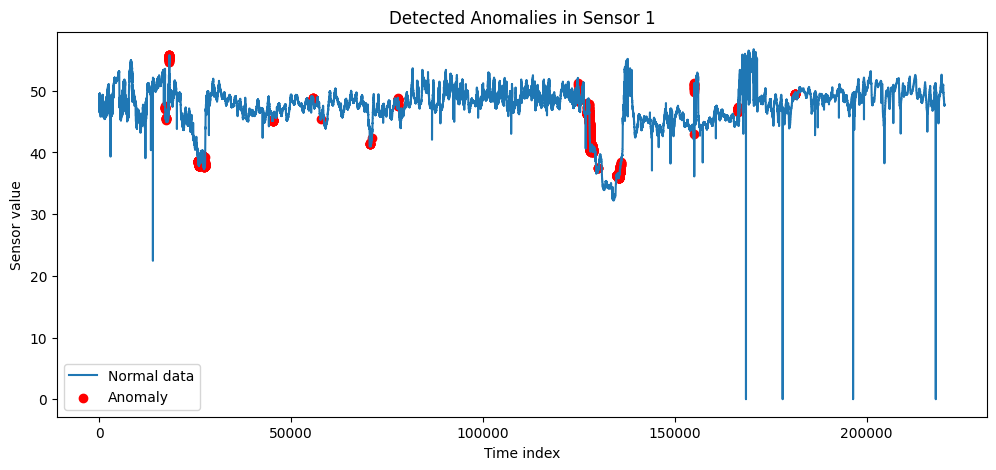

In [ ]:
plt.figure(figsize = (12,5))
plt.plot(data['sensor_01'], label = "Normal data")

anomalies = data[data['iso_anomaly'] == -1]

plt.scatter(anomalies.index, anomalies['sensor_01'], color = 'red', label = "Anomaly")

plt.title("Detected Anomalies in Sensor 1")
plt.xlabel("Time index")
plt.ylabel("Sensor value")
plt.legend()
plt.show()

#Online Deployment

In an industrial setting, the trained anomaly detection model could be used to monitor pump sensor data in real time.

New incoming sensor measurements would be processed by the model and assigned an anomaly score. If the score exceeds a predefined threshold, the system could send an alert to operators for further inspection.

#Comparison

The following table summarizes the strengths and weaknesses of the anomaly detection methods evaluated on the pump sensor dataset.

The dataset contains multivariate time series measurements from 52 sensors monitoring the operating condition of an industrial pump. The methods were evaluated based on how well they identify unusual patterns or deviations in the sensor signals.

| Method | Strength | Weakness |
|------|------|------|
| KMeans | Groups similar pump operating patterns based on sensor measurements | Assumes simple cluster shapes and may miss complex anomalies |
| Isolation Forest | Effective for high-dimensional sensor data and directly detects abnormal observations | Harder to interpret which sensor caused the anomaly |
| DBSCAN | Detects anomalies as low-density observations that differ from normal pump operation | Sensitive to parameter choice and computationally expensive for large datasets |

#Conclusion

This project applied unsupervised anomaly detection methods to multivariate pump sensor data in order to identify abnormal operating conditions.

Three algorithms were evaluated: K-Means, DBSCAN, and Isolation Forest. Among these methods, Isolation Forest performed best at detecting abnormal observations in the dataset.

The model detected approximately 1% anomalies (2204 observations), which correspond to sharp drops and unusual patterns in the sensor time series.

These anomalies may represent abnormal pump behavior and could help engineers detect potential equipment failures earlier.

Overall, anomaly detection models can support predictive maintenance by automatically monitoring sensor data and identifying unusual operating patterns in industrial systems.